In [1]:
import pandas as pd
import datetime
import numpy as np
import matplotlib.pyplot as plt
import os
from dateutil import parser

import math

%matplotlib widget

In [2]:
file_path = 'weather_1hr_2022.csv'

df = pd.read_csv(file_path)

# Read DataFrame
df = pd.read_csv(file_path,parse_dates={'ts':['Timestamp']})

# Rename Columns
df.rename(columns = {'Timestamp':'ts',
                        'SRRL BMS Diffuse Horizontal Irradiance':'dh',
                        'SRRL BMS Direct Normal Irradiance':'dn',
                        'SRRL BMS Dry Bulb Temperature':'db',
                        'SRRL BMS Relative Humidity':'rh',
                        'SRRL BMS Wet Bulb Temperature':'wb'},inplace=True)

# Remove kW, kWh
df['dh'] = df['dh'].str.replace('W/mÂ²_irr','').astype('float')
df['dn'] = df['dn'].str.replace('W/mÂ²_irr','').astype('float')
df['db'] = df['db'].str.replace('Â°F','').astype('float')
df['wb'] = df['wb'].str.replace('Â°F','').astype('float')
df['rh'] = df['rh'].str.replace('%RH','').astype('float')
df['ts'] = df['ts'].str.replace('-07:00 Denver',' MST')
df['ts'] = df['ts'].str.replace('-06:00 Denver',' MDT')

# Resolve Timezone
df['ts'] = [parser.parse(ts, tzinfos={"MDT": 1 * 3600,"MST": 0*3600}) for ts in df['ts']]
df['ts'] = pd.to_datetime(df['ts'],utc=True)

display(df)

C:\Users\harikan\AppData\Local\Temp\1\ipykernel_8588\1712611191.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(file_path,parse_dates={'ts':['Timestamp']})


,ts,dh,dn,db,rh,wb
0,2022-01-01 00:00:00+00:00,-0.930090,0.332826,12.47870,90.456667,11.864235
1,2022-01-01 01:00:00+00:00,-0.949883,0.439348,9.96290,88.763334,9.303317
2,2022-01-01 02:00:00+00:00,-1.125896,0.276817,7.97840,87.751666,7.310013
3,2022-01-01 03:00:00+00:00,-1.107202,0.418236,6.87950,87.166668,6.207735
4,2022-01-01 04:00:00+00:00,-1.043002,0.683536,4.93910,86.088333,4.263839
...,...,...,...,...,...,...
8755,2022-12-31 19:00:00+00:00,-1.086106,-0.027296,36.32447,69.983000,32.412759
8756,2022-12-31 20:00:00+00:00,-1.113351,-0.050579,36.00875,68.840833,31.982495
8757,2022-12-31 21:00:00+00:00,-1.048652,-0.083892,35.99486,66.768833,31.699917
8758,2022-12-31 22:00:00+00:00,-1.048328,-0.017964,36.37253,64.097666,31.676850


In [3]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype              
---  ------  --------------  -----              
 0   ts      8760 non-null   datetime64[ns, UTC]
 1   dh      8747 non-null   float64            
 2   dn      8749 non-null   float64            
 3   db      8750 non-null   float64            
 4   rh      8750 non-null   float64            
 5   wb      8750 non-null   float64            
dtypes: datetime64[ns, UTC](1), float64(5)
memory usage: 410.8 KB


None

Text(0.5, 1.0, 'Missing value in the dataset')

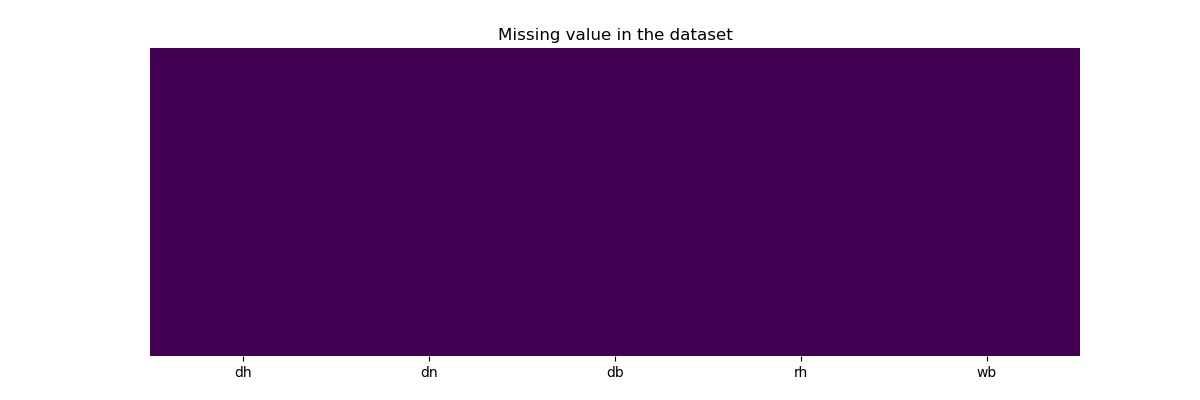

In [4]:
import seaborn as sns

x = df.drop('ts',axis = 1 )

plt.figure(figsize=(12,4))
sns.heatmap(x.isnull(),cbar=False,cmap='viridis',yticklabels=False)
plt.title('Missing value in the dataset')

In [5]:
missing_rows = df[df.isna().any(axis=1)]
missing_dates = missing_rows['ts']
print(missing_dates)

5556   2022-08-20 12:00:00+00:00
5578   2022-08-21 10:00:00+00:00
5579   2022-08-21 11:00:00+00:00
5762   2022-08-29 02:00:00+00:00
5763   2022-08-29 03:00:00+00:00
5764   2022-08-29 04:00:00+00:00
5765   2022-08-29 05:00:00+00:00
5766   2022-08-29 06:00:00+00:00
7444   2022-11-07 04:00:00+00:00
7445   2022-11-07 05:00:00+00:00
7446   2022-11-07 06:00:00+00:00
7447   2022-11-07 07:00:00+00:00
7448   2022-11-07 08:00:00+00:00
8568   2022-12-24 00:00:00+00:00
Name: ts, dtype: datetime64[ns, UTC]


In [6]:
df = df.interpolate()

print(df.iloc[5556])

ts    2022-08-20 12:00:00+00:00
dh                   419.564187
dn                    33.114544
db                      76.1414
rh                      44.8375
wb                    60.918918
Name: 5556, dtype: object


In [7]:
df.set_index('ts', inplace=True)

# Linear interpolation is done to create new 4 data points between each two hourly data 
df_resampled = df.resample('15T').interpolate(method='linear')

# Optionally, forward-fill any remaining missing values
df_resampled = df_resampled.ffill()

# Optionally, backward-fill any remaining missing values
# df_resampled = df_resampled.bfill()

# Print the resampled DataFrame
display(df_resampled)

,dh,dn,db,rh,wb
ts,,,,,
2022-01-01 00:00:00+00:00,-0.930090,0.332826,12.478700,90.456667,11.864235
2022-01-01 00:15:00+00:00,-0.935038,0.359456,11.849750,90.033334,11.224006
2022-01-01 00:30:00+00:00,-0.939986,0.386087,11.220800,89.610001,10.583776
2022-01-01 00:45:00+00:00,-0.944935,0.412718,10.591850,89.186667,9.943547
2022-01-01 01:00:00+00:00,-0.949883,0.439348,9.962900,88.763334,9.303317
...,...,...,...,...,...
2022-12-31 22:00:00+00:00,-1.048328,-0.017964,36.372530,64.097666,31.676850
2022-12-31 22:15:00+00:00,-1.041229,0.004448,36.120537,64.480791,31.514095
2022-12-31 22:30:00+00:00,-1.034130,0.026860,35.868545,64.863916,31.351340


In [8]:
file_path = 'Cafe Main Electricity 2022.csv'

df_energy = pd.read_csv(file_path)

display(df_energy)

,Timestamp,Cafe Main Energy Net,Cafe Main Real Power
0,2022-01-01 00:00:00 MST,5.7kWh,22.8kW
1,2022-01-01 00:15:00 MST,5.8kWh,24.0kW
2,2022-01-01 00:30:00 MST,5.8kWh,22.8kW
3,2022-01-01 00:45:00 MST,5.8kWh,23.6kW
4,2022-01-01 01:00:00 MST,5.8kWh,21.8kW
...,...,...,...
35035,2022-12-31 22:45:00 MST,4.3kWh,16.9kW
35036,2022-12-31 23:00:00 MST,4.9kWh,19.3kW
35037,2022-12-31 23:15:00 MST,4.9kWh,19.1kW
35038,2022-12-31 23:30:00 MST,5.0kWh,19.7kW


Text(0.5, 1.0, 'Missing value in the 2022 dataset')

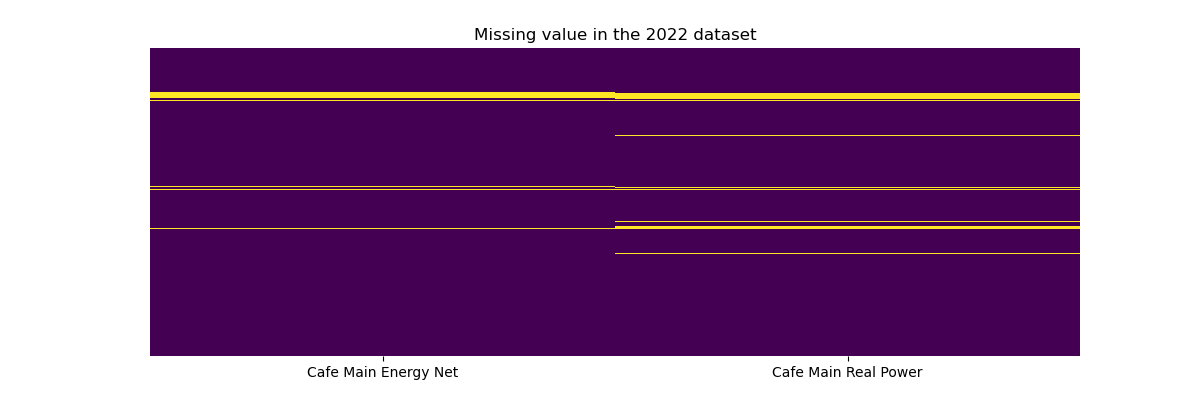

In [9]:
x2 = df_energy.drop('Timestamp',axis = 1 )

plt.figure(figsize=(12,4))
sns.heatmap(x2.isnull(),cbar=False,cmap='viridis',yticklabels=False)
plt.title('Missing value in the 2022 dataset')

Text(0.5, 1.0, 'Missing value in the 2023 dataset')

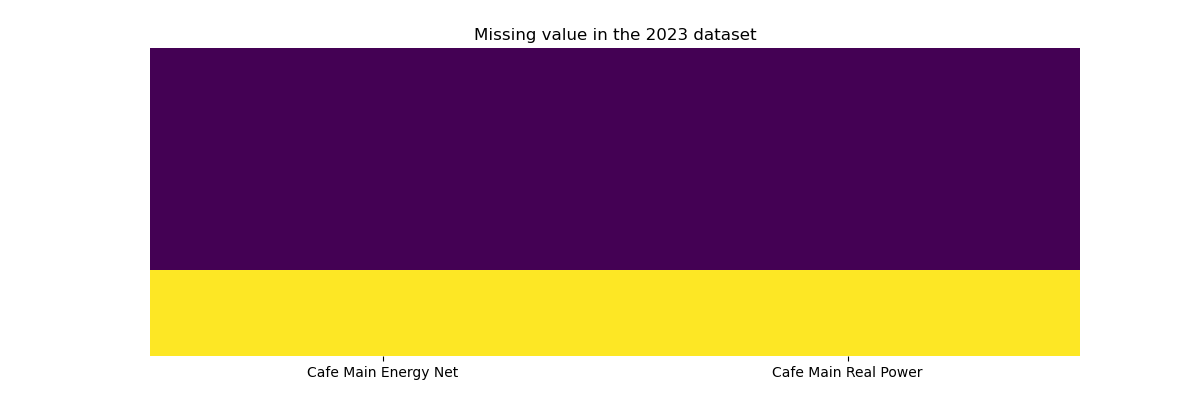

In [10]:
# df_energy = df_energy.interpolate()
file_path2 = 'Cafe Main Electricity 2023.csv'

df_energy_2023 = pd.read_csv(file_path2)

x3 = df_energy_2023.drop('Timestamp',axis = 1 )

plt.figure(figsize=(12,4))
sns.heatmap(x3.isnull(),cbar=False,cmap='viridis',yticklabels=False)
plt.title('Missing value in the 2023 dataset')

Text(0.5, 1.0, 'Missing value in the 2021 dataset')

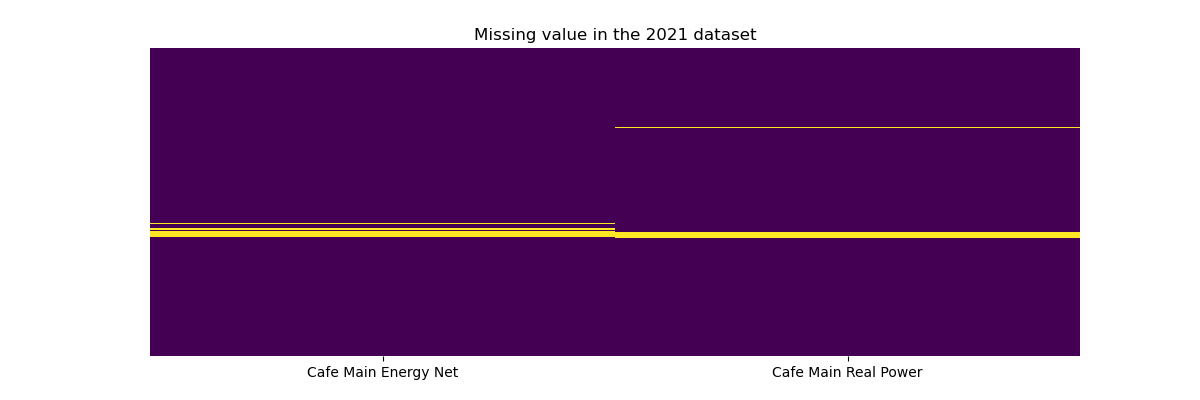

In [11]:
# df_energy = df_energy.interpolate()
file_path3 = 'Cafe Main Electricity 2021.csv'

df_energy_2021 = pd.read_csv(file_path3)

x4 = df_energy_2021.drop('Timestamp',axis = 1 )

plt.figure(figsize=(12,4))
sns.heatmap(x4.isnull(),cbar=False,cmap='viridis',yticklabels=False)
plt.title('Missing value in the 2021 dataset')

Using the 2022 Energy dataset and only the "Cafe Main Real Power" for the experimentation.

In [12]:
display(df_energy)

df_energy_2022 = df_energy.drop(['Cafe Main Energy Net'], axis = 1)

display(df_energy_2022)

,Timestamp,Cafe Main Energy Net,Cafe Main Real Power
0,2022-01-01 00:00:00 MST,5.7kWh,22.8kW
1,2022-01-01 00:15:00 MST,5.8kWh,24.0kW
2,2022-01-01 00:30:00 MST,5.8kWh,22.8kW
3,2022-01-01 00:45:00 MST,5.8kWh,23.6kW
4,2022-01-01 01:00:00 MST,5.8kWh,21.8kW
...,...,...,...
35035,2022-12-31 22:45:00 MST,4.3kWh,16.9kW
35036,2022-12-31 23:00:00 MST,4.9kWh,19.3kW
35037,2022-12-31 23:15:00 MST,4.9kWh,19.1kW
35038,2022-12-31 23:30:00 MST,5.0kWh,19.7kW


,Timestamp,Cafe Main Real Power
0,2022-01-01 00:00:00 MST,22.8kW
1,2022-01-01 00:15:00 MST,24.0kW
2,2022-01-01 00:30:00 MST,22.8kW
3,2022-01-01 00:45:00 MST,23.6kW
4,2022-01-01 01:00:00 MST,21.8kW
...,...,...
35035,2022-12-31 22:45:00 MST,16.9kW
35036,2022-12-31 23:00:00 MST,19.3kW
35037,2022-12-31 23:15:00 MST,19.1kW
35038,2022-12-31 23:30:00 MST,19.7kW


In [13]:
missing_rows2 = df_energy_2022[df_energy_2022.isna().any(axis=1)]
missing_dates2 = missing_rows2['Timestamp']
print(missing_dates2)

127      2022-01-02 07:45:00 MST
387      2022-01-05 00:45:00 MST
457      2022-01-05 18:15:00 MST
1049     2022-01-11 22:15:00 MST
1050     2022-01-11 22:30:00 MST
                  ...           
28203    2022-10-21 19:45:00 MDT
28209    2022-10-21 21:15:00 MDT
28211    2022-10-21 21:45:00 MDT
28213    2022-10-21 22:15:00 MDT
28219    2022-10-21 23:45:00 MDT
Name: Timestamp, Length: 1374, dtype: object


In [14]:
df_energy_2022['Cafe Main Real Power'] = df_energy_2022['Cafe Main Real Power'].str.replace('kW','').astype('float')

df_energy_2022 = df_energy_2022.interpolate()

print(df_energy_2022.iloc[127])


Timestamp               2022-01-02 07:45:00 MST
Cafe Main Real Power                      19.85
Name: 127, dtype: object


In [15]:
df_energy_2022.rename(columns={'Cafe Main Real Power': 'kW', 'Timestamp': 'ts'}, inplace=True)

df_energy_2022['ts'] = [parser.parse(ts, tzinfos={"MDT": 1 * 3600,"MST": 0*3600}) for ts in df_energy_2022['ts']]

df_energy_2022.set_index('ts', inplace=True)

display(df_energy_2022)


,kW
ts,
2022-01-01 00:00:00+00:00,22.8
2022-01-01 00:15:00+00:00,24.0
2022-01-01 00:30:00+00:00,22.8
2022-01-01 00:45:00+00:00,23.6
2022-01-01 01:00:00+00:00,21.8
...,...
2022-12-31 22:45:00+00:00,16.9
2022-12-31 23:00:00+00:00,19.3
2022-12-31 23:15:00+00:00,19.1


Now merge the energy and weather data together

In [16]:
df_combined = pd.concat([df_resampled,df_energy_2022],axis=1,join="inner")

# merged_df = pd.concat(df_resampled, df_energy_2022, on='ts', how='inner')

display(df_combined)

,dh,dn,db,rh,wb,kW
ts,,,,,,
2022-01-01 00:00:00+00:00,-0.930090,0.332826,12.478700,90.456667,11.864235,22.8
2022-01-01 00:15:00+00:00,-0.935038,0.359456,11.849750,90.033334,11.224006,24.0
2022-01-01 00:30:00+00:00,-0.939986,0.386087,11.220800,89.610001,10.583776,22.8
2022-01-01 00:45:00+00:00,-0.944935,0.412718,10.591850,89.186667,9.943547,23.6
2022-01-01 01:00:00+00:00,-0.949883,0.439348,9.962900,88.763334,9.303317,21.8
...,...,...,...,...,...,...
2022-12-31 22:00:00+00:00,-1.048328,-0.017964,36.372530,64.097666,31.676850,18.0
2022-12-31 22:15:00+00:00,-1.041229,0.004448,36.120537,64.480791,31.514095,18.1
2022-12-31 22:30:00+00:00,-1.034130,0.026860,35.868545,64.863916,31.351340,19.3


Add weekday (7 categorical features) and a national holiday feature

In [17]:
# change the indexing to integer to manipulate the data
df_combined.reset_index(drop=False, inplace=True)

df_combined['weekday'] = df_combined['ts'].dt.dayofweek

from sklearn.preprocessing import OneHotEncoder

# Initialize OneHotEncoder
encoder = OneHotEncoder()

# Fit and transform the weekday column
weekday_encoded = encoder.fit_transform(df_combined[['weekday']])

# Convert the encoded result to a DataFrame
weekday_encoded_df = pd.DataFrame(weekday_encoded.toarray(), columns=encoder.categories_[0])

# change encoded values to int from float
weekday_encoded_df = weekday_encoded_df.astype(int)

# add a string to each column name for clarification
weekday_encoded_df.columns = ['Weekday_' + str(col) for col in weekday_encoded_df.columns]

display(weekday_encoded_df)

# merge the columns
for column in weekday_encoded_df.columns:
    column_name_str = str(column)

    df_combined = df_combined.join(weekday_encoded_df[column], rsuffix= 'Weekday: ' + column_name_str)

# set index back to date time
df_combined.set_index('ts', inplace=True)


# Drop the weekday column
df_combined.drop(columns=['weekday'], inplace=True)

display(df_combined)   


,Weekday_0,Weekday_1,Weekday_2,Weekday_3,Weekday_4,Weekday_5,Weekday_6
0,0,0,0,0,0,1,0
1,0,0,0,0,0,1,0
2,0,0,0,0,0,1,0
3,0,0,0,0,0,1,0
4,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...
35032,0,0,0,0,0,1,0
35033,0,0,0,0,0,1,0
35034,0,0,0,0,0,1,0
35035,0,0,0,0,0,1,0


,dh,dn,db,rh,wb,kW,Weekday_0,Weekday_1,Weekday_2,Weekday_3,Weekday_4,Weekday_5,Weekday_6
ts,,,,,,,,,,,,,
2022-01-01 00:00:00+00:00,-0.930090,0.332826,12.478700,90.456667,11.864235,22.8,0,0,0,0,0,1,0
2022-01-01 00:15:00+00:00,-0.935038,0.359456,11.849750,90.033334,11.224006,24.0,0,0,0,0,0,1,0
2022-01-01 00:30:00+00:00,-0.939986,0.386087,11.220800,89.610001,10.583776,22.8,0,0,0,0,0,1,0
2022-01-01 00:45:00+00:00,-0.944935,0.412718,10.591850,89.186667,9.943547,23.6,0,0,0,0,0,1,0
2022-01-01 01:00:00+00:00,-0.949883,0.439348,9.962900,88.763334,9.303317,21.8,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-31 22:00:00+00:00,-1.048328,-0.017964,36.372530,64.097666,31.676850,18.0,0,0,0,0,0,1,0
2022-12-31 22:15:00+00:00,-1.041229,0.004448,36.120537,64.480791,31.514095,18.1,0,0,0,0,0,1,0
2022-12-31 22:30:00+00:00,-1.034130,0.026860,35.868545,64.863916,31.351340,19.3,0,0,0,0,0,1,0


In [18]:
df_combined.reset_index(drop=False, inplace=True)

df_combined['ts'] = pd.to_datetime(df_combined['ts'])

df_combined['National_holiday'] = '0'

# List of verified national holidays 
# MLK day           2022-01-17     -   
# Veterans day      2022-11-11     +
# Labor day         2022-09-05     +
# Memorial day      2022-05-30     +
# Christmas day     2022-12-26     +
# Washington's day  2022-02-21     +
# Thanksgiving day  2022-11-24     +
# July 4th          2022-07-04     +
# Juneteenth        2022-06-19     -    (This day is sunday. No energy difference expected)
national_holidays = ['2022-01-17', '2022-11-11', '2022-09-05', '2022-05-30', '2022-12-26', '2022-02-21', '2022-11-24', '2022-07-04', '2022-06-19']

# Iterate over each row and mark national holidays
for holiday_date in national_holidays:
    df_combined.loc[df_combined['ts'] == holiday_date, 'National_holiday'] = '1'

df_combined.set_index('ts', inplace=True)

# Print the updated dataset
display(df_combined)

,dh,dn,db,rh,wb,kW,Weekday_0,Weekday_1,Weekday_2,Weekday_3,Weekday_4,Weekday_5,Weekday_6,National_holiday
ts,,,,,,,,,,,,,,
2022-01-01 00:00:00+00:00,-0.930090,0.332826,12.478700,90.456667,11.864235,22.8,0,0,0,0,0,1,0,0
2022-01-01 00:15:00+00:00,-0.935038,0.359456,11.849750,90.033334,11.224006,24.0,0,0,0,0,0,1,0,0
2022-01-01 00:30:00+00:00,-0.939986,0.386087,11.220800,89.610001,10.583776,22.8,0,0,0,0,0,1,0,0
2022-01-01 00:45:00+00:00,-0.944935,0.412718,10.591850,89.186667,9.943547,23.6,0,0,0,0,0,1,0,0
2022-01-01 01:00:00+00:00,-0.949883,0.439348,9.962900,88.763334,9.303317,21.8,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-31 22:00:00+00:00,-1.048328,-0.017964,36.372530,64.097666,31.676850,18.0,0,0,0,0,0,1,0,0
2022-12-31 22:15:00+00:00,-1.041229,0.004448,36.120537,64.480791,31.514095,18.1,0,0,0,0,0,1,0,0
2022-12-31 22:30:00+00:00,-1.034130,0.026860,35.868545,64.863916,31.351340,19.3,0,0,0,0,0,1,0,0


In [19]:
df_combined.reset_index(drop=False, inplace=True)

# 1 is added only to 1 instance of the day which is at time 00:00
# modify the next 95 indices as well

# Find the indices where the value '1' occurs in the specific column
indices_1 = df_combined.index[df_combined['National_holiday'] == '1'].tolist()

# Iterate over each index and modify the next 95 columns
for index in indices_1:
    df_combined.iloc[index: index + 96, df_combined.columns.get_loc('National_holiday'): df_combined.columns.get_loc('National_holiday') + 95] = '1'

df_combined.set_index('ts', inplace=True)

In [20]:
# save the dataset. This data is for the LSTM algorithm. It doesn't have previous 12_h, and 24_h features.
df_combined.to_csv('Cafe_2022_for_LSTM.csv', index=True)

In [21]:
# Add 12 hour previous temps
shift_list = [12]
for i in shift_list:
    df_combined[f'db_{str(i)}h'] = df_combined['db'].shift(periods=4*i,fill_value=None)  # dp
    df_combined[f'wb_{str(i)}h'] = df_combined['wb'].shift(periods=4*i,fill_value=None)  # db  

# Add 24 hour previous temps
shift_list = [24]
for i in shift_list:
    df_combined[f'db_{str(i)}h'] = df_combined['db'].shift(periods=4*i,fill_value=None)  # dp
    df_combined[f'wb_{str(i)}h'] = df_combined['wb'].shift(periods=4*i,fill_value=None)  # db

display(df_combined)

,dh,dn,db,rh,wb,kW,Weekday_0,Weekday_1,Weekday_2,Weekday_3,Weekday_4,Weekday_5,Weekday_6,National_holiday,db_12h,wb_12h,db_24h,wb_24h
ts,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00+00:00,-0.930090,0.332826,12.478700,90.456667,11.864235,22.8,0,0,0,0,0,1,0,0,NaN,NaN,NaN,NaN
2022-01-01 00:15:00+00:00,-0.935038,0.359456,11.849750,90.033334,11.224006,24.0,0,0,0,0,0,1,0,0,NaN,NaN,NaN,NaN
2022-01-01 00:30:00+00:00,-0.939986,0.386087,11.220800,89.610001,10.583776,22.8,0,0,0,0,0,1,0,0,NaN,NaN,NaN,NaN
2022-01-01 00:45:00+00:00,-0.944935,0.412718,10.591850,89.186667,9.943547,23.6,0,0,0,0,0,1,0,0,NaN,NaN,NaN,NaN
2022-01-01 01:00:00+00:00,-0.949883,0.439348,9.962900,88.763334,9.303317,21.8,0,0,0,0,0,1,0,0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-31 22:00:00+00:00,-1.048328,-0.017964,36.372530,64.097666,31.676850,18.0,0,0,0,0,0,1,0,0,48.86678,38.300113,33.761540,27.702305
2022-12-31 22:15:00+00:00,-1.041229,0.004448,36.120537,64.480791,31.514095,18.1,0,0,0,0,0,1,0,0,49.84586,38.854436,33.925528,27.745095
2022-12-31 22:30:00+00:00,-1.034130,0.026860,35.868545,64.863916,31.351340,19.3,0,0,0,0,0,1,0,0,50.82494,39.408760,34.089515,27.787885


In [22]:
# drop the first day because we don't have previous 24h temperatures
df_combined = df_combined.dropna(subset=['db_24h'])

display(df_combined)

,dh,dn,db,rh,wb,kW,Weekday_0,Weekday_1,Weekday_2,Weekday_3,Weekday_4,Weekday_5,Weekday_6,National_holiday,db_12h,wb_12h,db_24h,wb_24h
ts,,,,,,,,,,,,,,,,,,
2022-01-02 00:00:00+00:00,-0.774991,-0.250116,21.118430,27.490167,14.626107,20.1,0,0,0,0,0,0,1,0,11.10500,9.761608,12.478700,11.864235
2022-01-02 00:15:00+00:00,-0.801696,-0.275942,21.668930,27.600708,15.066867,22.8,0,0,0,0,0,0,1,0,11.89481,10.376387,11.849750,11.224006
2022-01-02 00:30:00+00:00,-0.828401,-0.301768,22.219430,27.711250,15.507627,21.1,0,0,0,0,0,0,1,0,12.68462,10.991166,11.220800,10.583776
2022-01-02 00:45:00+00:00,-0.855105,-0.327594,22.769930,27.821792,15.948387,21.5,0,0,0,0,0,0,1,0,13.47443,11.605945,10.591850,9.943547
2022-01-02 01:00:00+00:00,-0.881810,-0.353420,23.320430,27.932333,16.389147,21.1,0,0,0,0,0,0,1,0,14.26424,12.220724,9.962900,9.303317
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-31 22:00:00+00:00,-1.048328,-0.017964,36.372530,64.097666,31.676850,18.0,0,0,0,0,0,1,0,0,48.86678,38.300113,33.761540,27.702305
2022-12-31 22:15:00+00:00,-1.041229,0.004448,36.120537,64.480791,31.514095,18.1,0,0,0,0,0,1,0,0,49.84586,38.854436,33.925528,27.745095
2022-12-31 22:30:00+00:00,-1.034130,0.026860,35.868545,64.863916,31.351340,19.3,0,0,0,0,0,1,0,0,50.82494,39.408760,34.089515,27.787885


In [23]:
# save the dataset. This data is for the ANN algorithm. It has previous 12_h, and 24_h features for the temperature values.
df_combined.to_csv('Cafe_2022_for_ANN.csv', index=True)

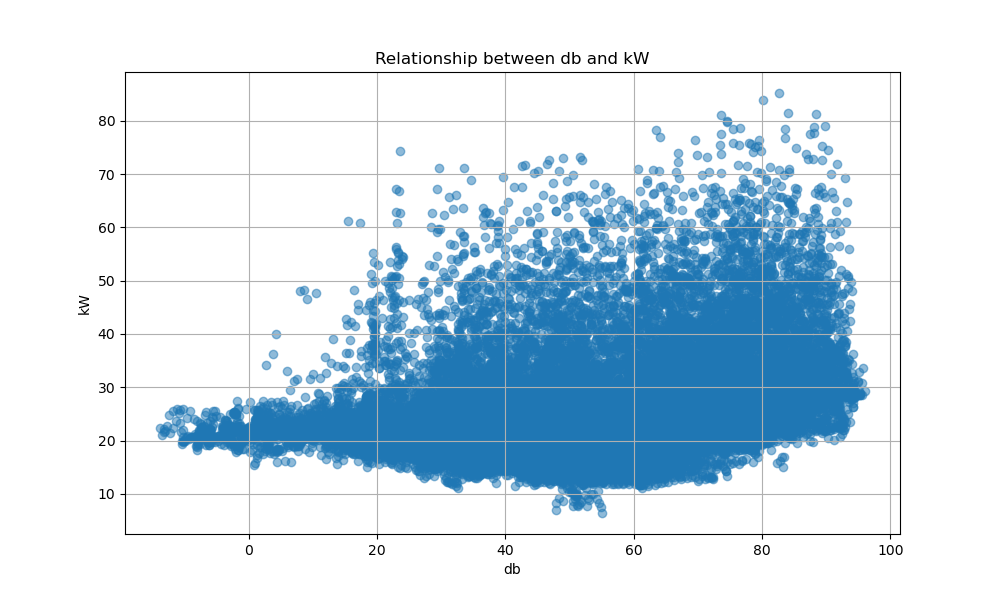

In [24]:
import matplotlib.pyplot as plt

# Assuming df is your DataFrame containing the dataset
plt.figure(figsize=(10, 6))
plt.scatter(df_combined['db'], df_combined['kW'], alpha=0.5)
plt.title('Relationship between db and kW')
plt.xlabel('db')
plt.ylabel('kW')
plt.grid(True)
plt.show()